(3, 7500)


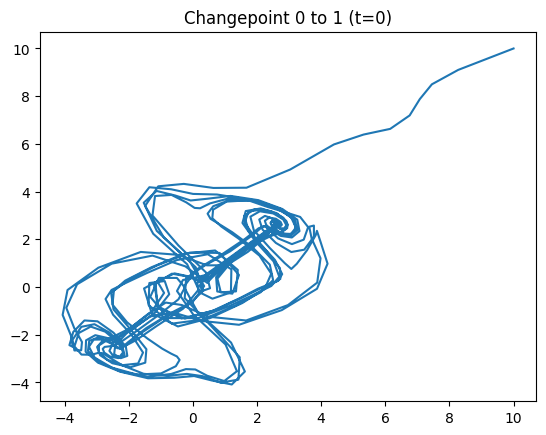

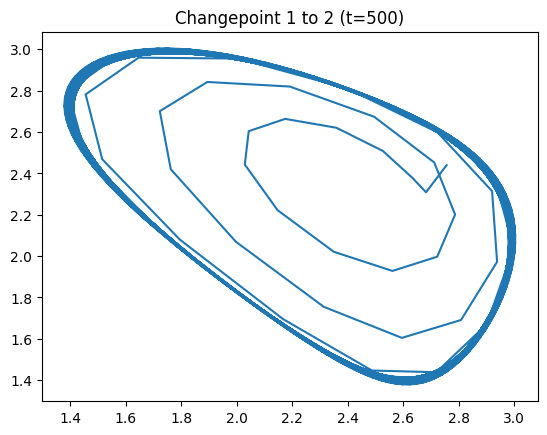

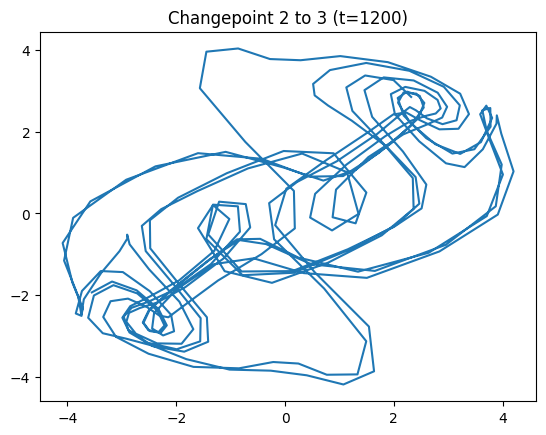

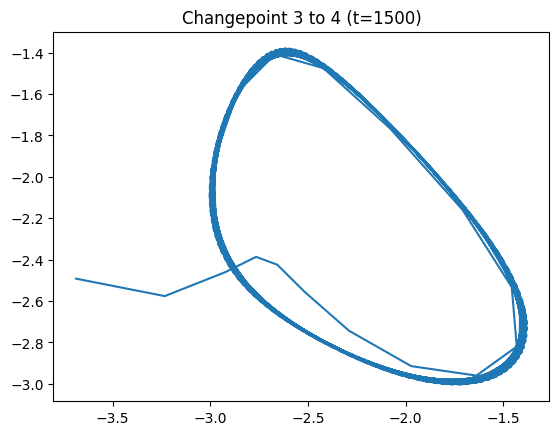

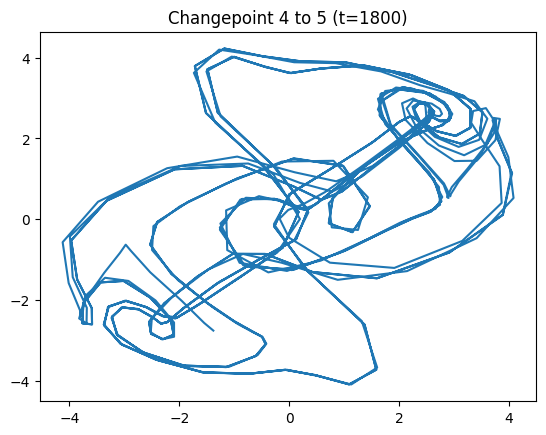

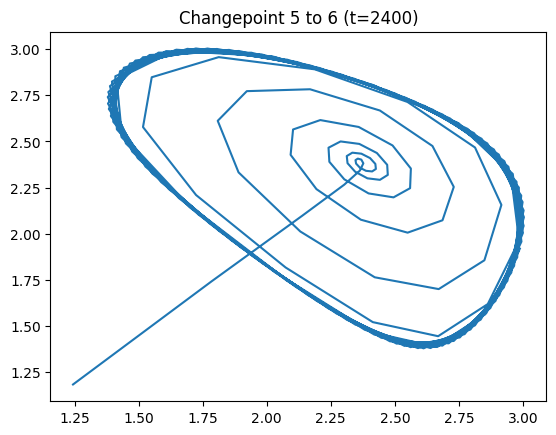

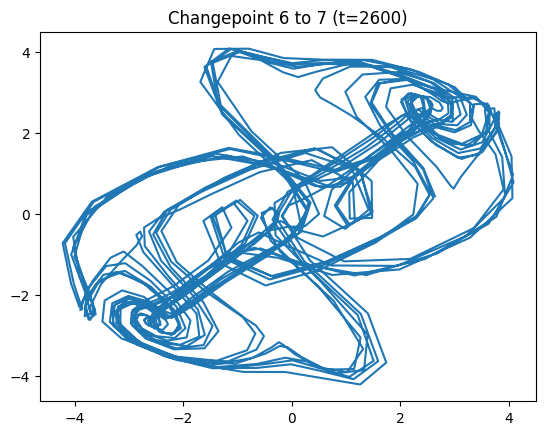

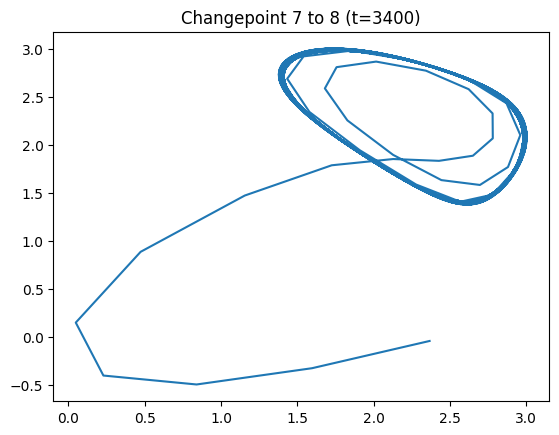

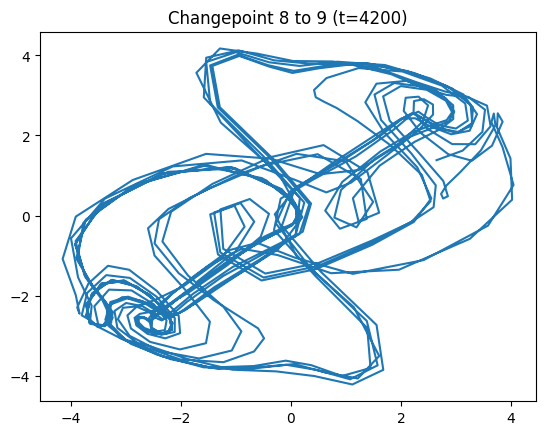

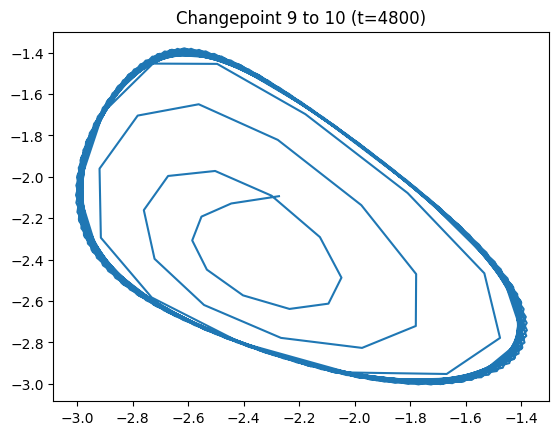

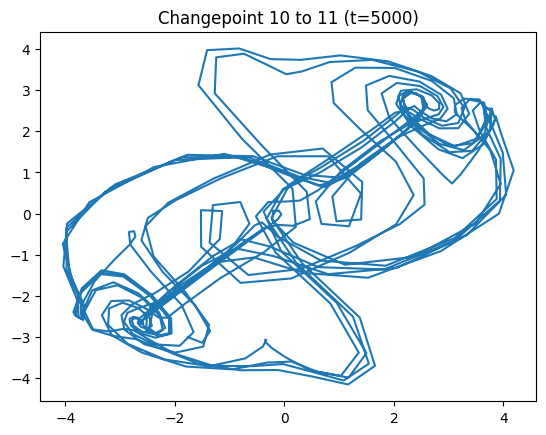

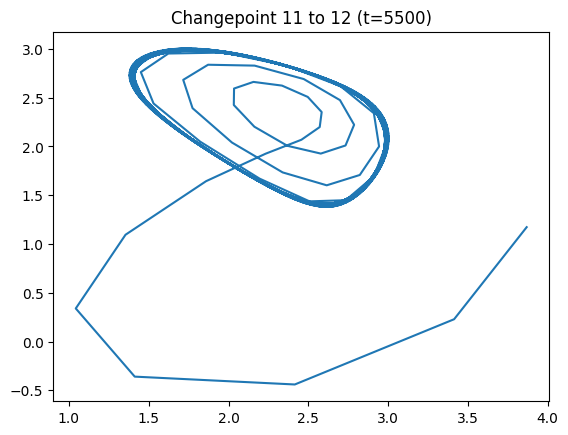

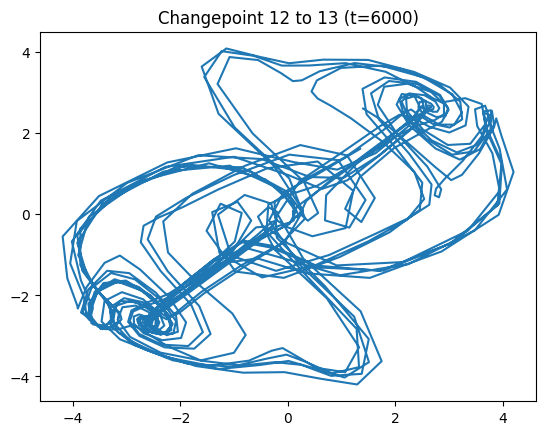

In [1]:
# Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exp = pd.read_csv("../data/thomas.csv",header=None)
train_input = exp.to_numpy().transpose()[1:,:-1] # of shape (spatial dimensions x time)
print(train_input.shape)

changetimes=np.array((0,500,1200,1500,1800,2400,2600,3400,4200,4800,5000,5500,6000,6700))

# test_data = pd.read_csv("../data/thomas_periodic_orbit.csv",header=None)
# test_data = test_data.to_numpy().transpose()[1:,:-1]
# print(test_data.shape)

for i in range(len(changetimes) - 1):
    plt.plot(train_input[0, changetimes[i]:changetimes[i + 1]], train_input[1, changetimes[i]:changetimes[i + 1]])
    plt.title("Changepoint %d to %d (t=%d)" % (i, i+1, changetimes[i]))
    plt.show()

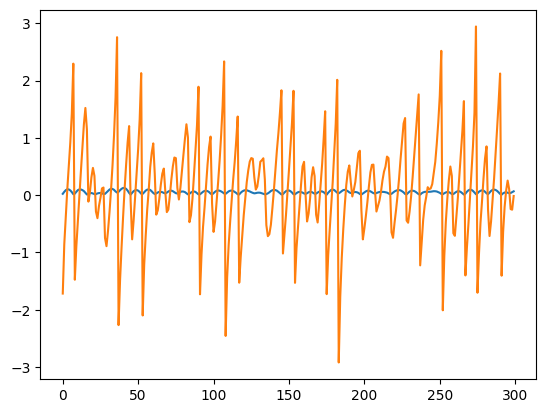

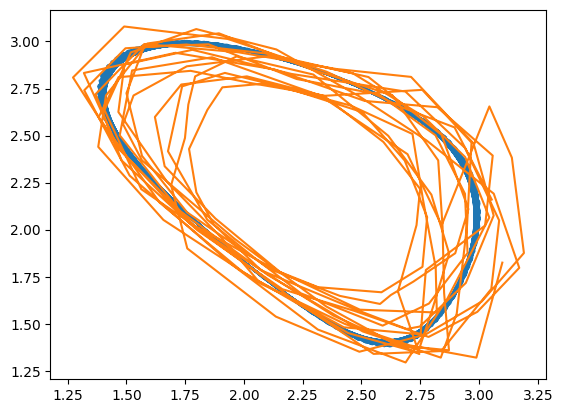

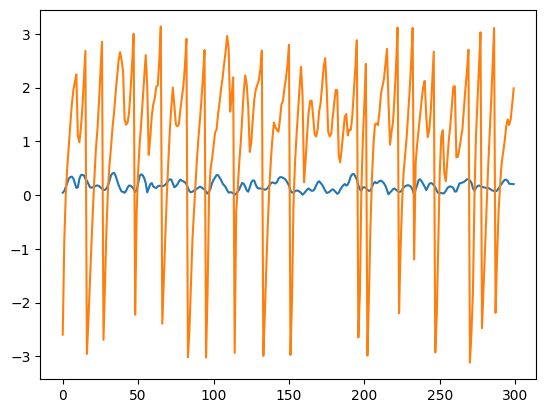

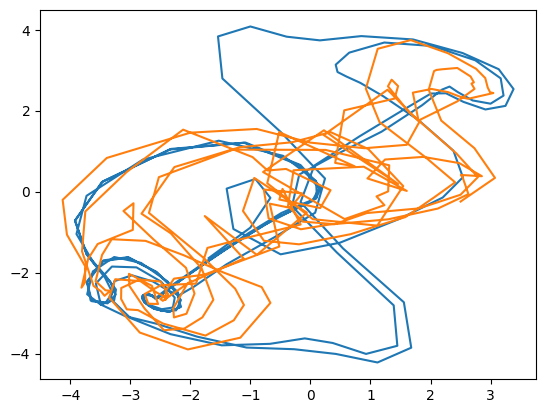

In [2]:
# Initialize network and train/predict on data to first and second changepoints
from rhythmic_sharing import RhythmicNetwork
from spike_sharing import SpikingNetwork

omega0 = 0.5

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=omega0
)

network.train(train_input[:, 500:1000], warmup_time=200)

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.show()

pred = network.predict(train_input[:, 500:1200], warmup_time=500)
plt.plot(train_input[0, 1000:1200], train_input[1, 1000:1200])
plt.plot(pred[0, :], pred[1, :])
plt.show()

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=omega0
)

network.train(train_input[:, 4200:4600], warmup_time=100)

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.show()

pred = network.predict(train_input[:, 4200:4800], warmup_time=400)
plt.plot(train_input[0, 4600:4800], train_input[1, 4600:4800])
plt.plot(pred[0, :], pred[1, :])
plt.show()

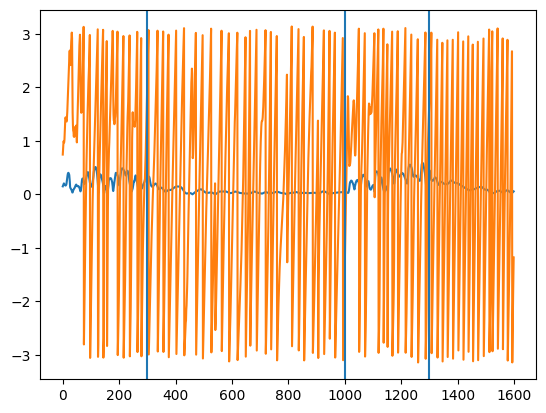

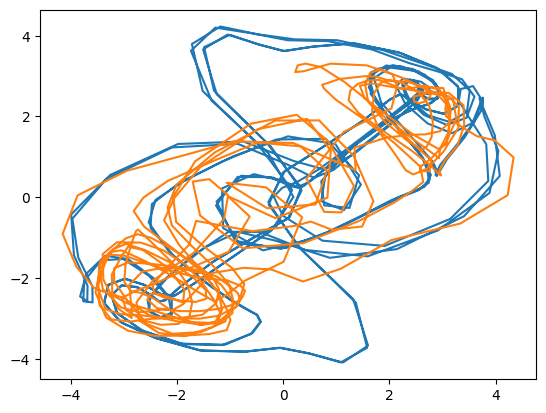

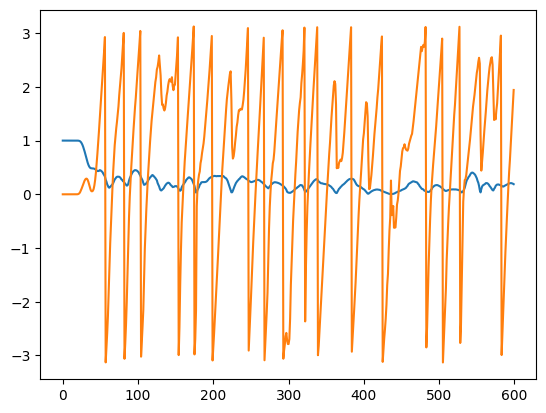

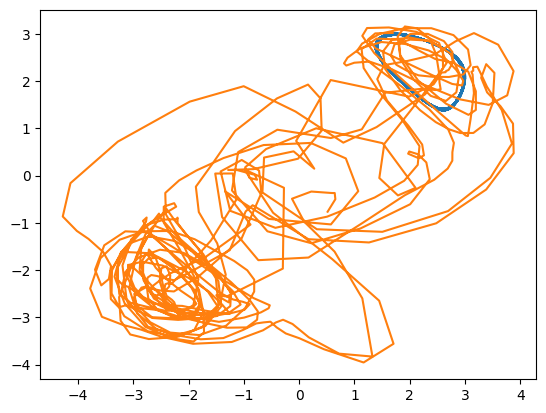

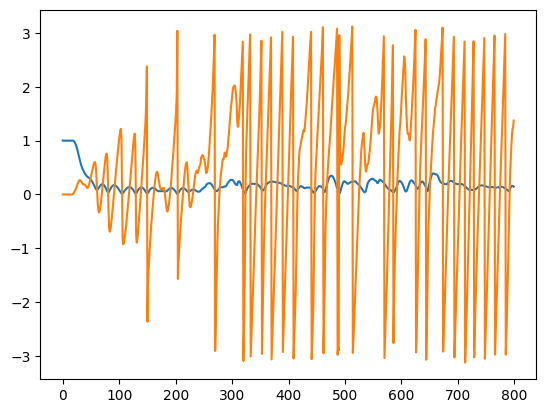

In [3]:
# Train on multiple dynamics and predict multiple dynamics

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=0.2
)

network.train(train_input[:, :1800], warmup_time=200)

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.axvline(1300)
plt.axvline(1000)
plt.axvline(300)
plt.show()

pred = network.predict(train_input[:, 1800:2400], warmup_time=200)
plt.plot(train_input[0, 2000:2400], train_input[1, 2000:2400])
plt.plot(pred[0, :], pred[1, :])
plt.show()

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.show()

pred = network.predict(train_input[:, 3400:4200], warmup_time=200)
plt.plot(train_input[0, 3600:4200], train_input[1, 3600:4200])
plt.plot(pred[0, :], pred[1, :])
plt.show()

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.show()